In [ ]:
# access file from Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_path = '/content/drive/My Drive/ESIIL Project Data/Discharge Data - Douglas_Eagle_Logan.csv'
df_discharge = pd.read_csv(file_path)

display(df_discharge.head())
display(df_discharge.info())

,YEAR,Douglas Discharge,Eagle Discharge,Logan Discharge
0,1985.0,63.8,2873.0,1143.0
1,1986.0,22.6,2938.0,941.9
2,1987.0,68.3,1760.0,1062.0
3,1988.0,46.8,1742.0,589.2
4,1989.0,8.9,1462.0,302.5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   YEAR               38 non-null     float64
 1   Douglas Discharge  38 non-null     float64
 2   Eagle Discharge    38 non-null     float64
 3   Logan Discharge    38 non-null     float64
dtypes: float64(4)
memory usage: 1.3 KB


None

# Task
Perform an ANOVA analysis on the discharge data for Douglas, Eagle, and Logan counties for the time periods 1985-2001, 2002-2022, and 1985-2022 using the data from "/content/drive/My Drive/ESIIL Project Data/Population Data/Discharge Data - Douglas_Eagle_Logan.csv".

## Data preparation

### Subtask:
Ensure the 'YEAR' column is treated as an integer or datetime object as appropriate for filtering.


**Reasoning**:
Convert the 'YEAR' column to integer type to ensure it is treated correctly for filtering.



In [ ]:
df_discharge['YEAR'] = df_discharge['YEAR'].astype(int)
display(df_discharge.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   YEAR               38 non-null     int64  
 1   Douglas Discharge  38 non-null     float64
 2   Eagle Discharge    38 non-null     float64
 3   Logan Discharge    38 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 1.3 KB


None

## Filter data for each time period

### Subtask:
Create separate DataFrames for the years 1985-2001, 2002-2022, and 1985-2022.


**Reasoning**:
Create the dataframes for the specified year ranges and display their heads to verify the filtering.



In [ ]:
df_1985_2001 = df_discharge[(df_discharge['YEAR'] >= 1985) & (df_discharge['YEAR'] <= 2001)].copy()
df_2002_2022 = df_discharge[(df_discharge['YEAR'] >= 2002) & (df_discharge['YEAR'] <= 2022)].copy()
df_1985_2022 = df_discharge[(df_discharge['YEAR'] >= 1985) & (df_discharge['YEAR'] <= 2022)].copy()

print("Head of df_1985_2001:")
display(df_1985_2001.head())

print("\nHead of df_2002_2022:")
display(df_2002_2022.head())

print("\nHead of df_1985_2022:")
display(df_1985_2022.head())

Head of df_1985_2001:


,YEAR,Douglas Discharge,Eagle Discharge,Logan Discharge
0,1985,63.8,2873.0,1143.0
1,1986,22.6,2938.0,941.9
2,1987,68.3,1760.0,1062.0
3,1988,46.8,1742.0,589.2
4,1989,8.9,1462.0,302.5



Head of df_2002_2022:


,YEAR,Douglas Discharge,Eagle Discharge,Logan Discharge
17,2002,7.3,898.1,139.1
18,2003,24.3,1407.0,31.4
19,2004,17.3,1160.0,12.1
20,2005,54.0,1635.0,133.2
21,2006,13.9,1913.0,64.1



Head of df_1985_2022:


,YEAR,Douglas Discharge,Eagle Discharge,Logan Discharge
0,1985,63.8,2873.0,1143.0
1,1986,22.6,2938.0,941.9
2,1987,68.3,1760.0,1062.0
3,1988,46.8,1742.0,589.2
4,1989,8.9,1462.0,302.5


## Perform anova

### Subtask:
For each time period, perform a one-way ANOVA test to compare the discharge data across the three counties (Douglas, Eagle, and Logan).


**Reasoning**:
Import the f_oneway function from scipy.stats and perform the one-way ANOVA tests for each time period and store the results.



In [ ]:
from scipy.stats import f_oneway

# Perform ANOVA for 1985-2001
f_oneway_1985_2001 = f_oneway(df_1985_2001['Douglas Discharge'],
                              df_1985_2001['Eagle Discharge'],
                              df_1985_2001['Logan Discharge'])

# Perform ANOVA for 2002-2022
f_oneway_2002_2022 = f_oneway(df_2002_2022['Douglas Discharge'],
                              df_2002_2022['Eagle Discharge'],
                              df_2002_2022['Logan Discharge'])

# Perform ANOVA for 1985-2022
f_oneway_1985_2022 = f_oneway(df_1985_2022['Douglas Discharge'],
                              df_1985_2022['Eagle Discharge'],
                              df_1985_2022['Logan Discharge'])

print("ANOVA results for 1985-2001:")
print(f"F-statistic: {f_oneway_1985_2001.statistic:.2f}, p-value: {f_oneway_1985_2001.pvalue:.3f}")

print("\nANOVA results for 2002-2022:")
print(f"F-statistic: {f_oneway_2002_2022.statistic:.2f}, p-value: {f_oneway_2002_2022.pvalue:.3f}")

print("\nANOVA results for 1985-2022:")
print(f"F-statistic: {f_oneway_1985_2022.statistic:.2f}, p-value: {f_oneway_1985_2022.pvalue:.3f}")

ANOVA results for 1985-2001:
F-statistic: 82.99, p-value: 0.000

ANOVA results for 2002-2022:
F-statistic: 74.57, p-value: 0.000

ANOVA results for 1985-2022:
F-statistic: 150.84, p-value: 0.000


## Present results

### Subtask:
Display the results of the ANOVA tests for each period, including p-values and F-statistics.


**Reasoning**:
Display the F-statistic and p-value for the ANOVA tests for each period as requested in the instructions.



In [ ]:
print("ANOVA results for 1985-2001:")
print(f"F-statistic: {f_oneway_1985_2001.statistic:.2f}, p-value: {f_oneway_1985_2001.pvalue:.3f}")

print("\nANOVA results for 2002-2022:")
print(f"F-statistic: {f_oneway_2002_2022.statistic:.2f}, p-value: {f_oneway_2002_2022.pvalue:.3f}")

print("\nANOVA results for 1985-2022:")
print(f"F-statistic: {f_oneway_1985_2022.statistic:.2f}, p-value: {f_oneway_1985_2022.pvalue:.3f}")

ANOVA results for 1985-2001:
F-statistic: 82.99, p-value: 0.000

ANOVA results for 2002-2022:
F-statistic: 74.57, p-value: 0.000

ANOVA results for 1985-2022:
F-statistic: 150.84, p-value: 0.000


## Interpret results

### Subtask:
Interpret the findings from the ANOVA tests.


## Summary:

### Data Analysis Key Findings

*   The ANOVA test for the 1985-2001 period showed a statistically significant difference in mean discharge across Douglas, Eagle, and Logan counties (F-statistic: 82.99, p-value: 0.000).
*   Similarly, the ANOVA test for the 2002-2022 period indicated a statistically significant difference in mean discharge among the three counties (F-statistic: 74.57, p-value: 0.000).
*   Over the entire 1985-2022 period, the ANOVA test also revealed a statistically significant difference in mean discharge across the counties (F-statistic: 150.84, p-value: 0.000).

### Insights or Next Steps

*   Since the ANOVA tests indicate significant differences, post-hoc tests (e.g., Tukey's HSD) could be performed to identify which specific county pairs have significantly different mean discharge rates in each time period.
*   Investigate potential factors contributing to the observed differences in discharge rates between the counties, such as land use patterns, population growth, water management practices, or climate variations.


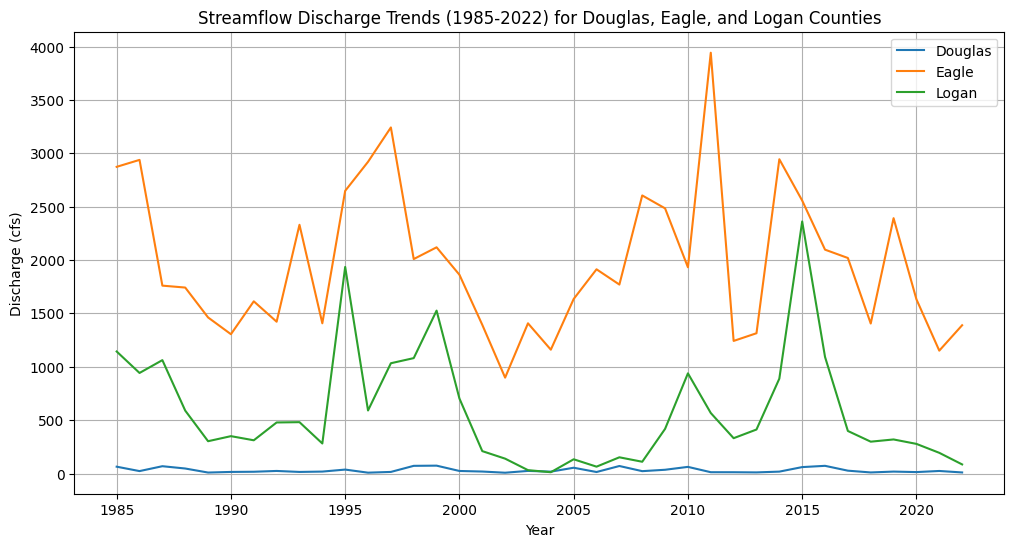

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_discharge, x='YEAR', y='Douglas Discharge', label='Douglas')
sns.lineplot(data=df_discharge, x='YEAR', y='Eagle Discharge', label='Eagle')
sns.lineplot(data=df_discharge, x='YEAR', y='Logan Discharge', label='Logan')

plt.title('Streamflow Discharge Trends (1985-2022) for Douglas, Eagle, and Logan Counties')
plt.xlabel('Year')
plt.ylabel('Discharge (cfs)')
plt.legend()
plt.grid(True)
plt.show()